In [32]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:
# Neural Network
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, x):
        return torch.exp(-x**2) * self.net(x)

model = PINN().to(device)

In [35]:
# Training data
x1 = torch.linspace(0, 2, 1000)
x2 = torch.linspace(2, 4, 3000)  # more focus here
x = torch.cat([x1, x2]).reshape(-1,1).to(device)
x = (x - 2.0) / 2.0   # normalize to [-1,1]
x = x.to(device)
x.requires_grad = True


In [36]:
# Boundary points (helps stabilize edges)
x_bc = torch.tensor([[0.0], [4.0]]).to(device)

In [37]:
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [38]:
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1)

def closure():
    optimizer_lbfgs.zero_grad()
    y = model(x)
    dy_dx = torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True)[0]
    loss = torch.mean((dy_dx + 2*x*y)**2) + (model(torch.tensor([[0.0]]).to(device)) - 1)**2
    loss.backward()
    return loss

optimizer_lbfgs.step(closure)

tensor([[1.3256]], grad_fn=<AddBackward0>)

In [39]:
# Training
epochs = 3000
ic_weight = 7

In [40]:
for epoch in range(epochs):
    optimizer.zero_grad()

    y = model(x)

    # First derivative
    dy_dx = torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

    # ODE loss: dy/dx + 2xy = 0
    ode_loss = torch.mean((dy_dx + 2*x*y)**2)

    # Initial condition y(0)=1
    x0 = torch.tensor([[0.0]]).to(device)
    y0 = model(x0)
    ic_loss = (y0 - 1)**2

    loss = 10 * ode_loss + ic_loss

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.07185637205839157
Epoch 500, Loss: 1.7096775764002814e-06
Epoch 1000, Loss: 1.4914175153535325e-05
Epoch 1500, Loss: 9.959909448298276e-07
Epoch 2000, Loss: 8.357818614967982e-07
Epoch 2500, Loss: 1.2028042419842677e-06


In [41]:
# Testing
x_test = torch.linspace(0, 4, 1000).reshape(-1,1).to(device)
y_pred = model(x_test).detach().cpu().numpy()

In [42]:
# Exact solution
x_np = x_test.cpu().numpy()
y_exact = np.exp(-x_np**2)

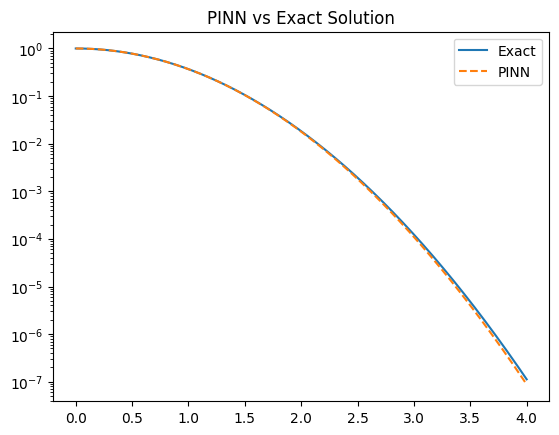

In [43]:
# Plot
plt.plot(x_np, y_exact, label="Exact")
plt.plot(x_np, y_pred, '--', label="PINN")
plt.legend()
plt.yscale("log")
plt.title("PINN vs Exact Solution")
plt.show()